# Ray tracing simulation # 

In [1]:
import os, importlib
import mitsuba as mi
print(mi.variants())

# mi.set_variant("llvm_ad_rgb")
mi.set_variant("llvm_ad_mono_polarized")

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, ITURadioMaterial

import sionna
from importlib.metadata import version
print("Sionna version:", version("sionna"))

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import util


['scalar_rgb', 'scalar_spectral', 'scalar_spectral_polarized', 'llvm_ad_rgb', 'llvm_ad_mono', 'llvm_ad_mono_polarized', 'llvm_ad_spectral', 'llvm_ad_spectral_polarized', 'cuda_ad_rgb', 'cuda_ad_mono', 'cuda_ad_mono_polarized', 'cuda_ad_spectral', 'cuda_ad_spectral_polarized']
Sionna version: 2.0.0


no-name-1      itu-concrete
elm__7         itu-glass
Directivity [dB]: 2.15
Gain [dB]: 2.16
Efficiency [%]: 1e+02
([1.64091], [1.643], [1.00128])
[[0, -0.0642857, 0],
 [0, -0.0214286, 0],
 [0, 0.0214286, 0],
 [0, 0.0642857, 0]]


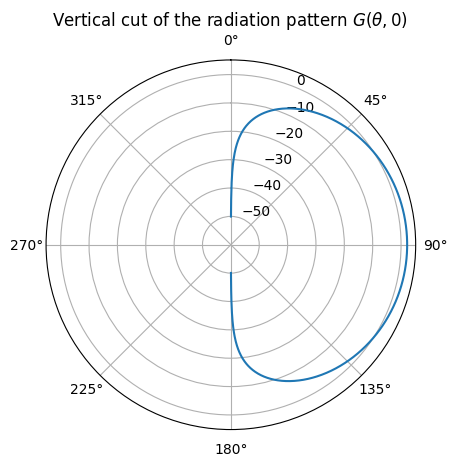

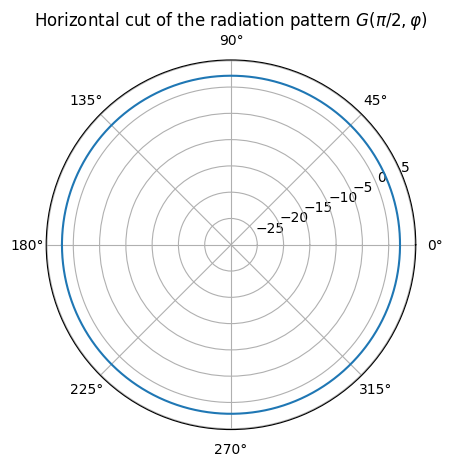

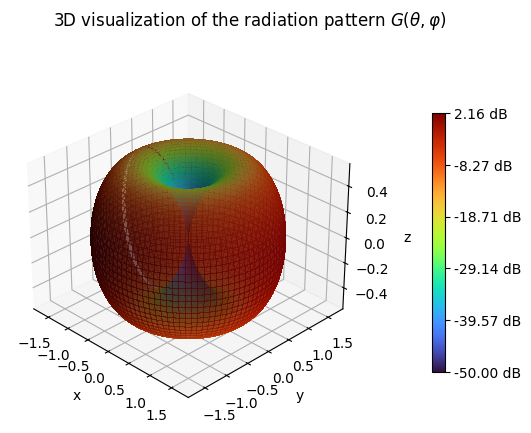

In [2]:
# Import scene as xml file
scene = load_scene("SimpleConfig/SimpleConfig.xml")

scene.radio_materials["itu-concrete"].thickness = 0.2

# print("Available materials:", scene.radio_materials.keys())
# mat = scene.radio_materials["itu-concrete"]
# print(f"Material: {mat.name}")
# print(f"Conductivity: {mat.conductivity.numpy()} S/m")
# print(f"Relative Permittivity: {mat.relative_permittivity.numpy()}")
# print(f"Thickness: {mat.thickness.numpy()} m")

ground = ITURadioMaterial("ground",
                        "concrete",
                        thickness=1,
                        color=[0.011, 0.27, 0.8])

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

ground_object = scene.objects["elm__7"]
ground_object.radio_material = ground

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='hw_dipole',
                             polarization='V')

num_rx_ant = 4
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=num_rx_ant,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='hw_dipole',
                             polarization='V')

print(scene.rx_array.antenna_pattern.compute_gain())
print(scene.rx_array.positions(3e8/3.5e9))
scene.rx_array.antenna_pattern.show()

# Tx position
TX_position = [5.5, 3.5, 1.5]

tx = Transmitter("tx", TX_position)
scene.add(tx)

# Rx positions
num_rx = 8
RX_positions = [[-7, 8, 1.5], 
                [0, 8, 1.5], 
                [7, 8, 1.5], 
                [9, 0, 1.5], 
                [-9, 0, 1.5], 
                [-7, -8, 1.5], 
                [0, -8, 1.5], 
                [7, -8, 1.5]]

num_rx = 4
RX_positions = [[-7, 8, 1.5], 
                [7, 8, 1.5],
                [-7, -8, 1.5],
                [7, -8, 1.5]]

RX_orientations = [[-np.pi/4, 0, 0], 
                   [-np.pi/2, 0, 0], 
                   [-3*np.pi/4, 0, 0], 
                   [np.pi, 0, 0], 
                   [0, 0, 0], 
                   [np.pi/4, 0, 0], 
                   [np.pi/2, 0, 0], 
                   [3*np.pi/4, 0, 0]]

RX_orientations = [[-np.pi/4, 0, 0], 
                    [-3*np.pi/4, 0, 0], 
                    [np.pi/4, 0, 0],
                    [3*np.pi/4, 0, 0]]

rx1 = Receiver("rx", RX_positions[0], RX_orientations[0])
rx2 = Receiver("rx2", RX_positions[1], RX_orientations[1])
rx3 = Receiver("rx3", RX_positions[2], RX_orientations[2])
rx4 = Receiver("rx4", RX_positions[3], RX_orientations[3])
# rx5 = Receiver("rx5", RX_positions[4], RX_orientations[4])
# rx6 = Receiver("rx6", RX_positions[5], RX_orientations[5])
# rx7 = Receiver("rx7", RX_positions[6], RX_orientations[6])
# rx8 = Receiver("rx8", RX_positions[7], RX_orientations[7])
scene.add(rx1)
scene.add(rx2)
scene.add(rx3)
scene.add(rx4)
# scene.add(rx5)
# scene.add(rx6)
# scene.add(rx7)
# scene.add(rx8)

scene.preview()

In [3]:
### System parameters ###

# Band sampling parameters
B = 50e6
T = 1 / B
osr = 8
Fs = B * osr
Ts = 1 / Fs

# Transmit power
P_TX_dBm = 0
P_TX_lin = 10 ** (P_TX_dBm / 10) / 1000

S_RX_dBm = -90
S_RX_lin = 10 ** (S_RX_dBm / 10) / 1000

### Paths computations ###

In [4]:
pathSolver = PathSolver()
paths = pathSolver(scene=scene, max_depth=15)

# 1. Get current valid mask to know the correct shape
# This is crucial: 'valid' might have fewer dimensions than 'a'
original_valid_np = paths.valid.numpy()
target_shape = original_valid_np.shape

# 2. Get signal magnitude from 'a'
a_r, a_i = paths.a
a_r_np, a_i_np = a_r.numpy(), a_i.numpy()
magnitudes = np.sqrt(a_r_np**2 + a_i_np**2)

# 3. Reduce magnitude to match 'valid' shape
# If 'a' has extra antenna dimensions (dims 1 and 3), max over them
# Example: Convert [Rx, RxAnt, Tx, TxAnt, Paths] -> [Rx, Tx, Paths]
if len(magnitudes.shape) > len(target_shape):
    # Reduce dimensions 1 and 3 (antenna arrays) by taking the max power across antennas
    # Adjust axes based on your actual shape. Typically:
    # Axis 0=Rx, 1=RxAnt, 2=Tx, 3=TxAnt, 4=Paths
    reduced_magnitudes = np.max(magnitudes, axis=(1, 3)) 
else:
    reduced_magnitudes = magnitudes

# 4. Create the filter mask
# Keep paths where power is > 5% of peak
keep_mask = np.zeros(target_shape, dtype=bool)

# Iterate over Rx/Tx pairs to calculate local thresholds
for i in range(target_shape[0]): # Rx
    for j in range(target_shape[1]): # Tx
        # Get all paths for this link
        path_powers = reduced_magnitudes[i, j, :]
        max_val = np.max(path_powers)
        
        if max_val > 0:
            # Create boolean filter
            keep_mask[i, j, :] = path_powers >= (0.2 * max_val)

# 5. Combine with original validity (Logical AND)
# This ensures we don't accidentally "revive" non-existent paths
final_mask = keep_mask & original_valid_np

# 6. Apply to the internal _valid variable
# Use TensorXb (Extended Boolean Tensor)
paths._valid = mi.TensorXb(final_mask)

# 7. (Optional) Zero out 'a' for consistency
# You might need to broadcast the mask back to 'a's shape if they differ
paths._a = (
    mi.TensorXf(a_r_np * final_mask[:, None, :, None, :]), # Broadcast if needed
    mi.TensorXf(a_i_np * final_mask[:, None, :, None, :])
)


In [5]:
scene.preview(paths=paths)

[ 0.          1.33767874  2.67535739 -2.27014913]
[ 0.          1.40496312  2.80992598 -2.06829623]
[-0.         -0.13079038 -0.26158067 -0.39237108]
[-0.         -1.91546189  2.45226162  0.5367997 ]


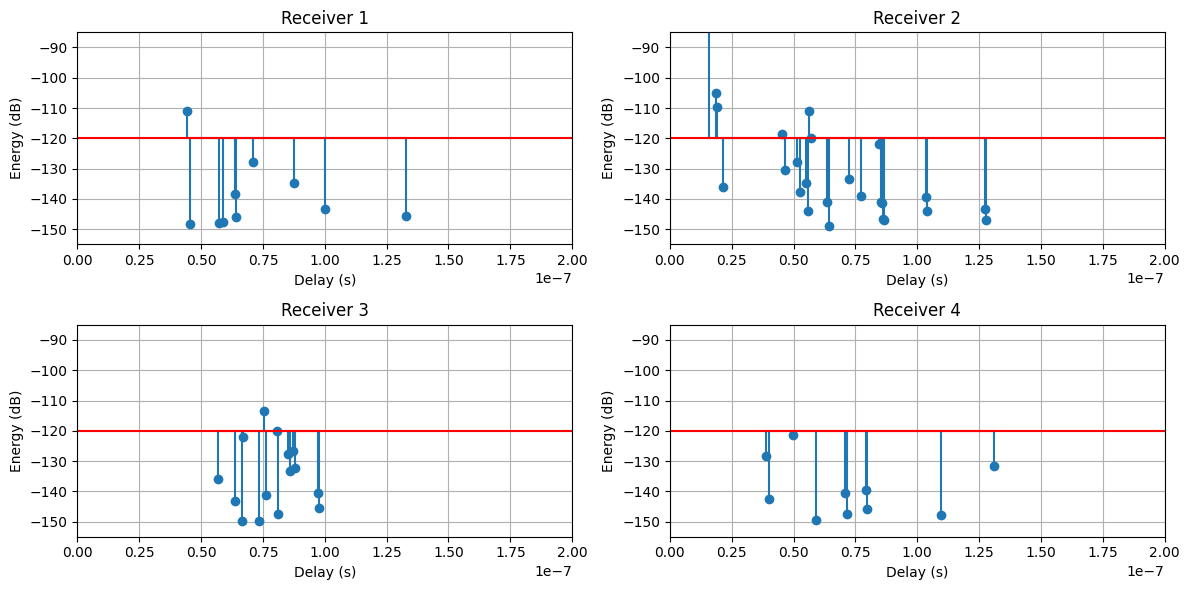

In [6]:
importlib.reload(util)

# Channel impulse response of the path
cir = paths.cir(sampling_frequency=3.5e9,
                num_time_steps=1,
                normalize_delays=False)

angles = paths.phi_r

a, tau, angles = util.format_paths(cir, angles, array=True)

# Scale a with transmit power
a = [a_i * np.sqrt(P_TX_lin) for a_i in a]

for i in range(len(a)):
    print(np.angle(a[i][:, 0] / a[i][0, 0]))

# Energy of paths
magnitudes = [np.abs(a[i]) for i in range(num_rx)]
energies = [magnitudes[i]**2 for i in range(num_rx)]


# Filter paths too weak
threshold = -150 # in dB, relative to P_TX
threshold_lin = 10 ** (threshold / 10)

for i in range(num_rx):
    mask = energies[i] >= threshold_lin
    a[i] = a[i][mask].reshape(num_rx_ant, -1)
    tau[i] = tau[i][mask[0]]
    angles[i] = angles[i][mask[0]]
    magnitudes[i] = magnitudes[i][mask].reshape(num_rx_ant, -1)
    energies[i] = energies[i][mask].reshape(num_rx_ant, -1)


plt.figure(figsize=(12, 6))
for i in range(num_rx):
    plt.subplot(2, num_rx//2, i+1)
    plt.stem(tau[i], 10*np.log10(energies[i][0]), bottom=10*np.log10(S_RX_lin))
    plt.axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
    plt.title(f"Receiver {i+1}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Energy (dB)")
    plt.xlim(0, 2e-7)
    plt.ylim(-155, -85)
    plt.grid()
plt.tight_layout()

3.372102323358629e-11
3.350777185462467e-11


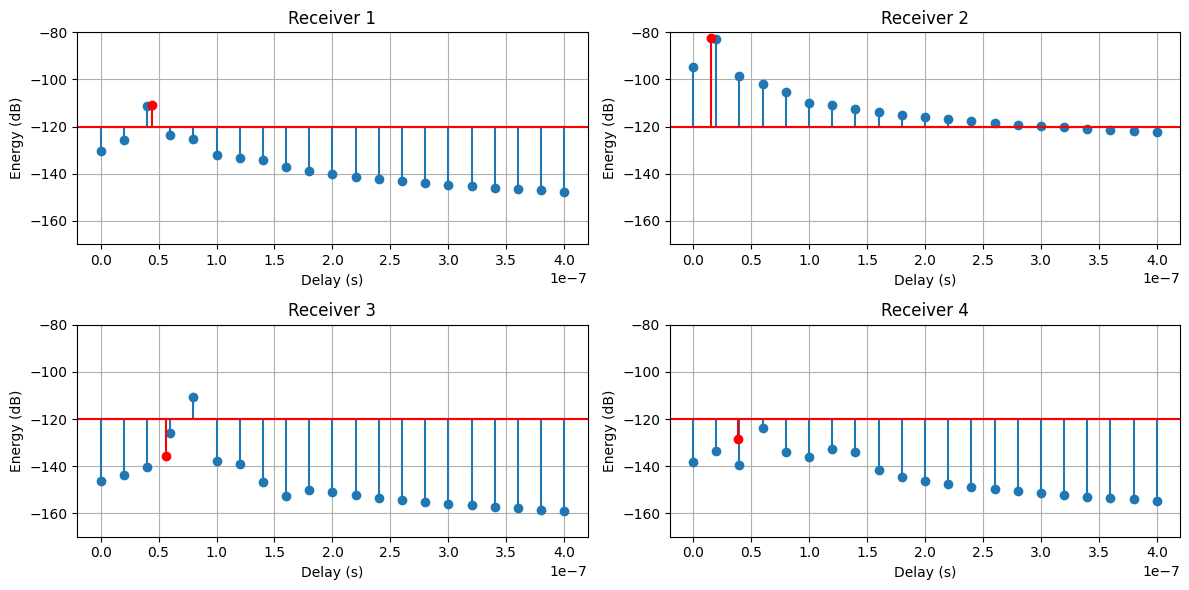

In [7]:
# Channel impulse response of the path
l_min, l_max = 0, 20
t = np.arange(l_min, l_max+1) / B

taps = paths.taps(bandwidth=B, l_min=l_min, l_max=l_max, normalize_delays=False)
taps_re, taps_im = taps[0], taps[1]
taps_re = taps_re.numpy().reshape(taps_re.shape[0], num_rx_ant, -1) * np.sqrt(P_TX_lin)
taps_im = taps_im.numpy().reshape(taps_im.shape[0], num_rx_ant, -1) * np.sqrt(P_TX_lin)
taps_lin = taps_re + 1j * taps_im
taps_mag = np.sqrt(taps_re**2 + taps_im**2)
taps_energy = taps_mag ** 2


print(np.sum(taps_energy[0]))
print(np.sum(energies[0]))


plt.figure(figsize=(12, 6))
for i in range(num_rx):
    plt.subplot(2, num_rx//2, i+1)
    plt.stem(t, 10*np.log10(taps_energy[i][0]), bottom=10*np.log10(S_RX_lin))
    plt.stem(tau[i][0], 10*np.log10(energies[i][0][0]), bottom=10*np.log10(S_RX_lin), linefmt='r-', markerfmt='ro', label='Path Energies')
    plt.axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
    plt.title(f"Receiver {i+1}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Energy (dB)")
    plt.xlim((l_min-1)/B, (l_max+1)/B)
    plt.ylim(-170, -80)
    plt.grid()
plt.tight_layout()

In [8]:
import Multipath as mp
import Comm as com
importlib.reload(mp)
importlib.reload(com)

B = 100e6
fft_size = 256
RX_idx = 3
music_spectrum, music_tau, music_angles, K, estimated_channel = mp.MUSIC_2D_spectrum(a[RX_idx], tau[RX_idx], B, fc=3.5e9, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)
# music_a, music_taus = mp.MUSIC_taps_time(music_spectrum, music_tau, B/fft_size, estimated_channel)


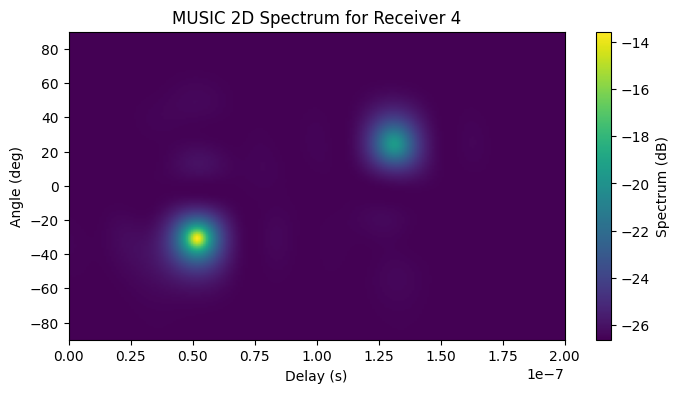

In [9]:
local_angles = util.format_local_angles(angles, RX_orientations)

plt.figure(figsize=(8, 4))
plt.imshow(10*np.log10(music_spectrum.T), extent=(music_tau[0], music_tau[-1], music_angles[0]*180/np.pi, music_angles[-1]*180/np.pi), aspect='auto', origin='lower')
# plt.scatter(tau[RX_idx], local_angles[RX_idx]*180/np.pi, label='True Paths', color='red', marker='x')
plt.title(f"MUSIC 2D Spectrum for Receiver {RX_idx+1}")
plt.xlabel("Delay (s)")
plt.ylabel("Angle (deg)")
plt.colorbar(label='Spectrum (dB)')
plt.show()

Optimal number of paths: 3


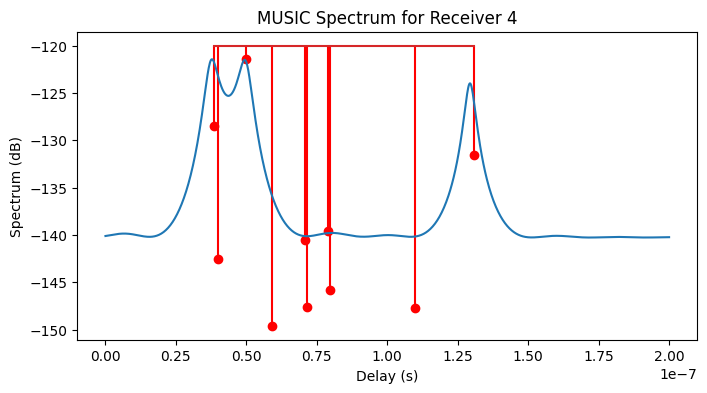

In [10]:
importlib.reload(mp)
importlib.reload(com)

music_spectrum, music_tau, K, estimated_channel = mp.MUSIC_spectrum(a[RX_idx][0], tau[RX_idx], B, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)

plt.figure(figsize=(8, 4))
plt.stem(tau[RX_idx], 10*np.log10(energies[RX_idx][0]), markerfmt='ro', linefmt='r-', label='True Path Energies', bottom=10*np.log10(S_RX_lin))
plt.plot(music_tau, 10*np.log10(music_spectrum*np.max(energies[RX_idx][0])/np.max(music_spectrum)), label='MUSIC Spectrum')
plt.title(f"MUSIC Spectrum for Receiver {RX_idx+1}")
plt.xlabel("Delay (s)")
plt.ylabel("Spectrum (dB)")
plt.show()

In [11]:
importlib.reload(mp)
importlib.reload(com)

music_spectrums = []
music_taus = []
music_angles = []
music_Ks = []
music_h_hats = []
for RX_idx in range(num_rx):
    music_spectrum, music_tau, music_angle, music_K, music_h_hat = mp.MUSIC_2D_spectrum(a[RX_idx], tau[RX_idx], B, fc=3.5e9, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)
    music_spectrums.append(music_spectrum)
    music_taus.append(music_tau)
    music_angles.append(music_angle)
    music_Ks.append(music_K)
    music_h_hats.append(music_h_hat)

C:\Users\louis\AppData\Local\Temp\ipykernel_14136\2976018842.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[RX_idx//2, RX_idx%2].legend()


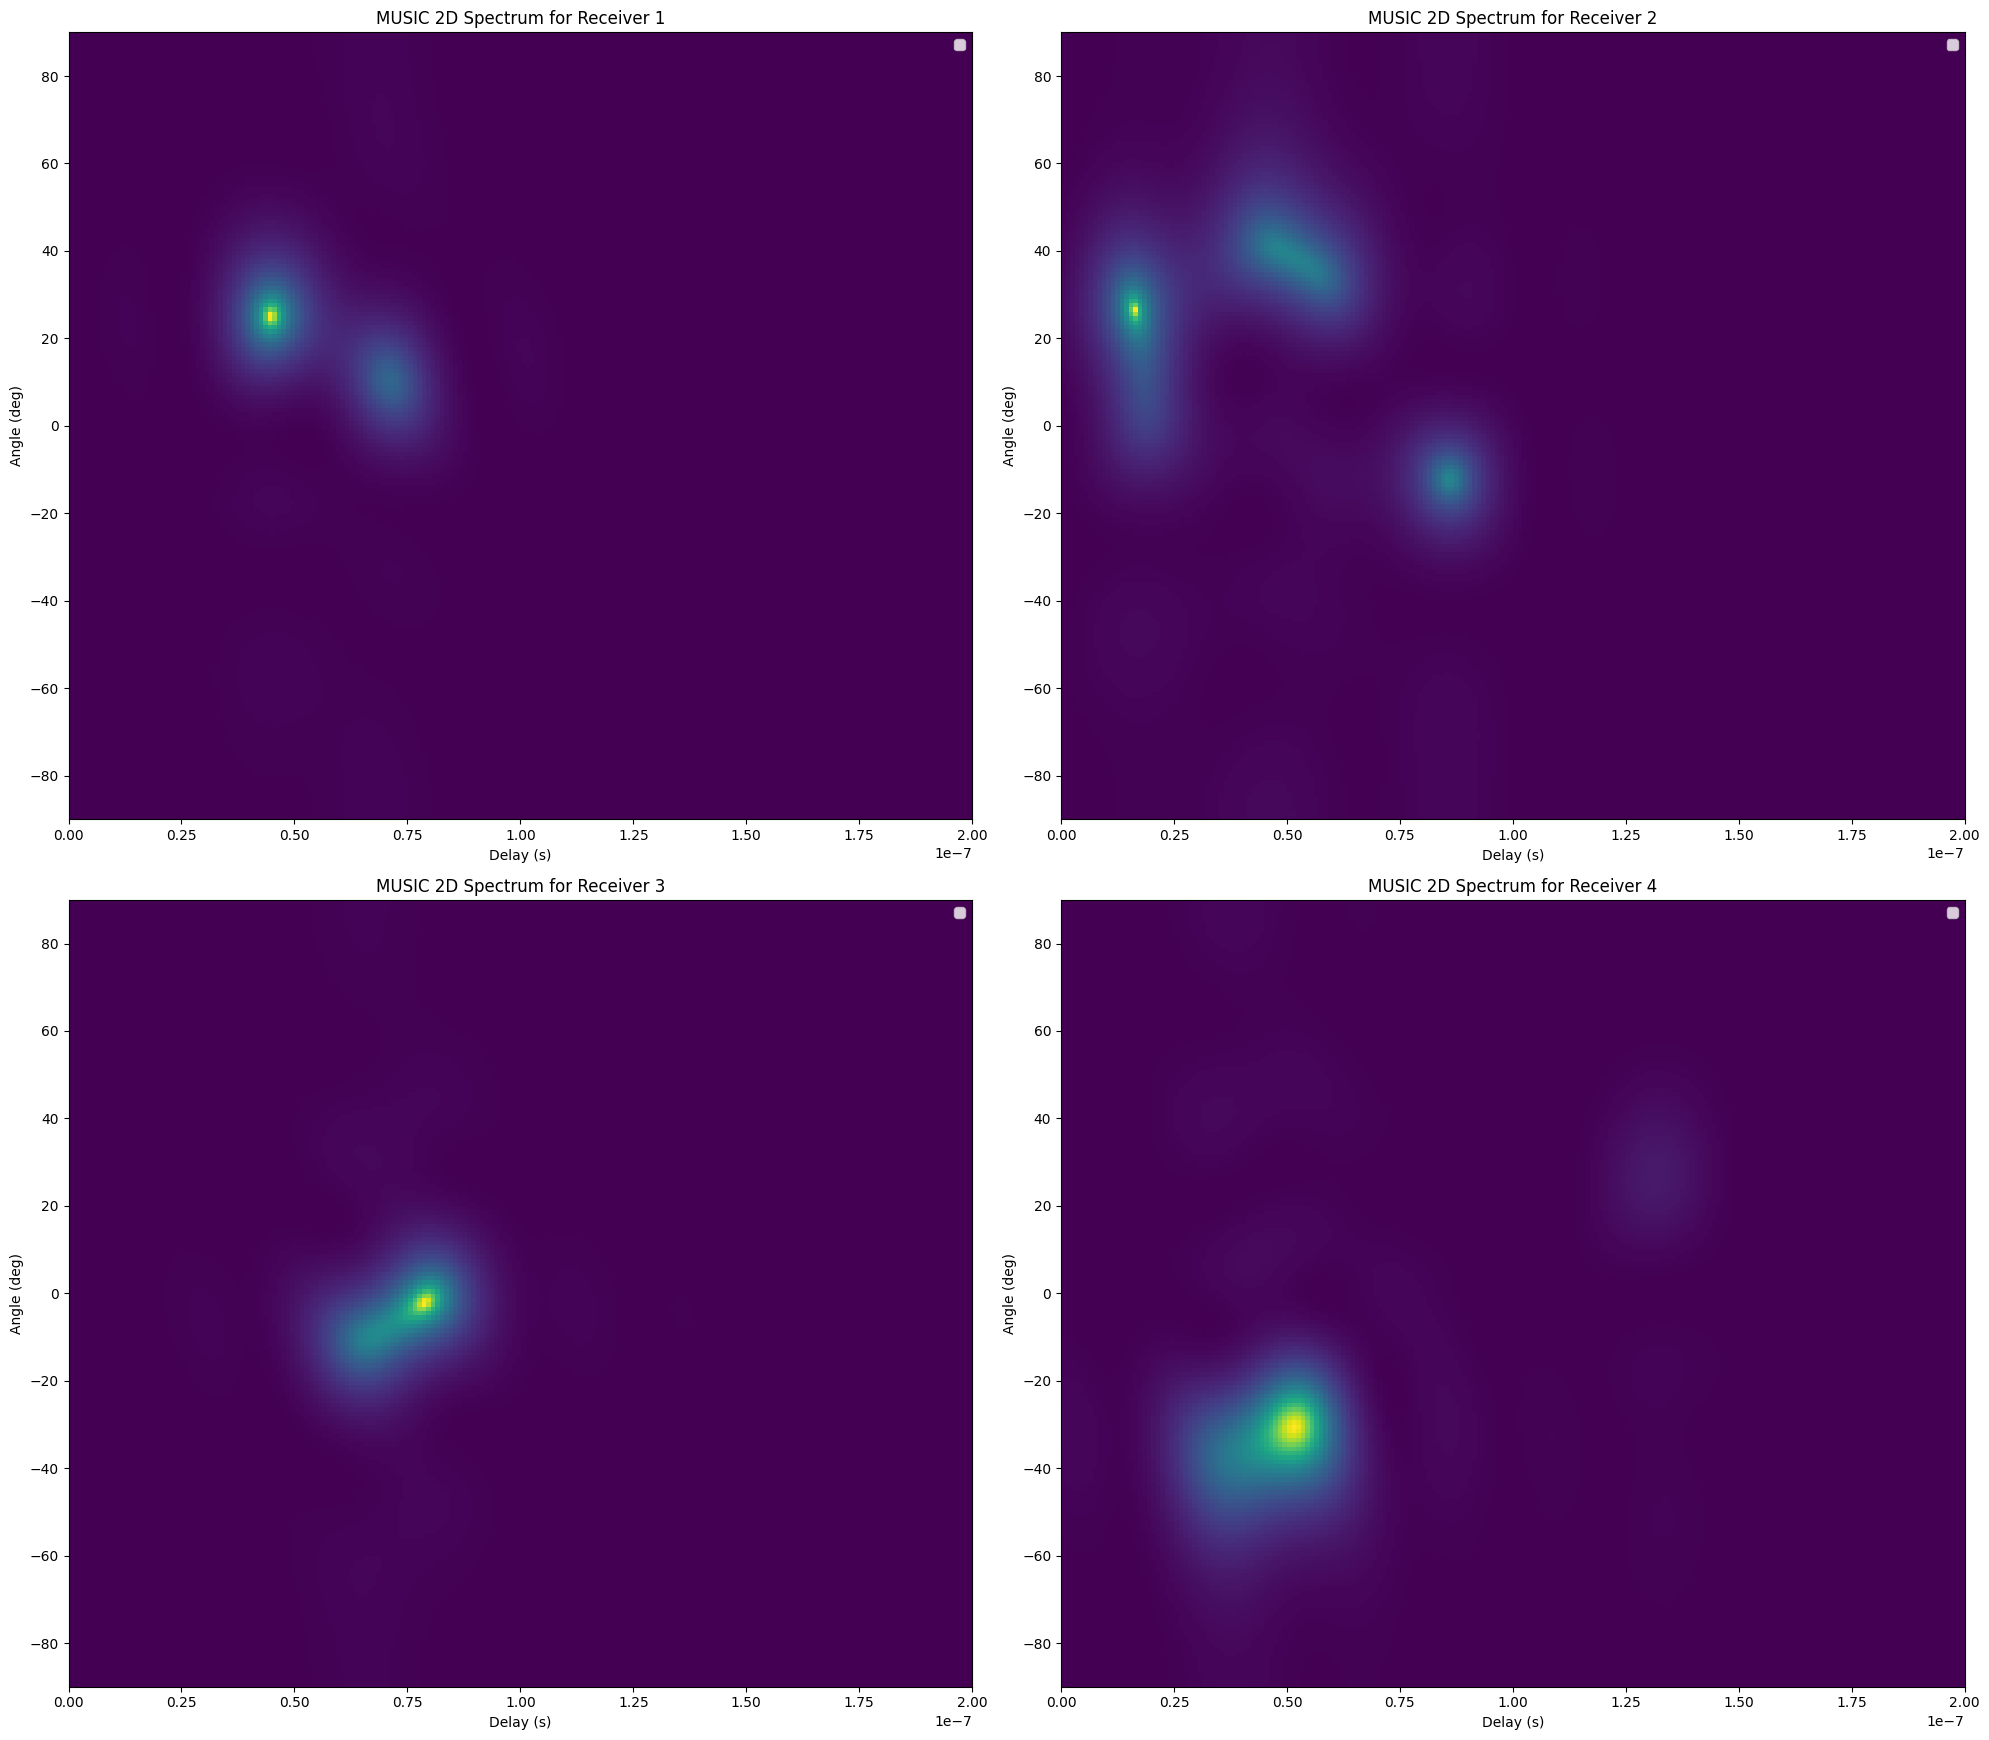

In [12]:
fig, ax = plt.subplots(num_rx//2, 2, figsize=(20, 35/8*num_rx))
for RX_idx in range(num_rx):
    ax[RX_idx//2, RX_idx%2].imshow(10*np.log10(music_spectrums[RX_idx].T), extent=(music_taus[RX_idx][0], music_taus[RX_idx][-1], music_angles[RX_idx][0]*180/np.pi, music_angles[RX_idx][-1]*180/np.pi), aspect='auto', origin='lower')
    # ax[RX_idx//2, RX_idx%2].scatter(tau[RX_idx], local_angles[RX_idx]*180/np.pi, label='True Paths', color='red', marker='x')
    ax[RX_idx//2, RX_idx%2].set_title(f"MUSIC 2D Spectrum for Receiver {RX_idx+1}")
    ax[RX_idx//2, RX_idx%2].set_xlabel("Delay (s)")
    ax[RX_idx//2, RX_idx%2].set_ylabel("Angle (deg)")
    ax[RX_idx//2, RX_idx%2].legend()
plt.tight_layout()
plt.show()

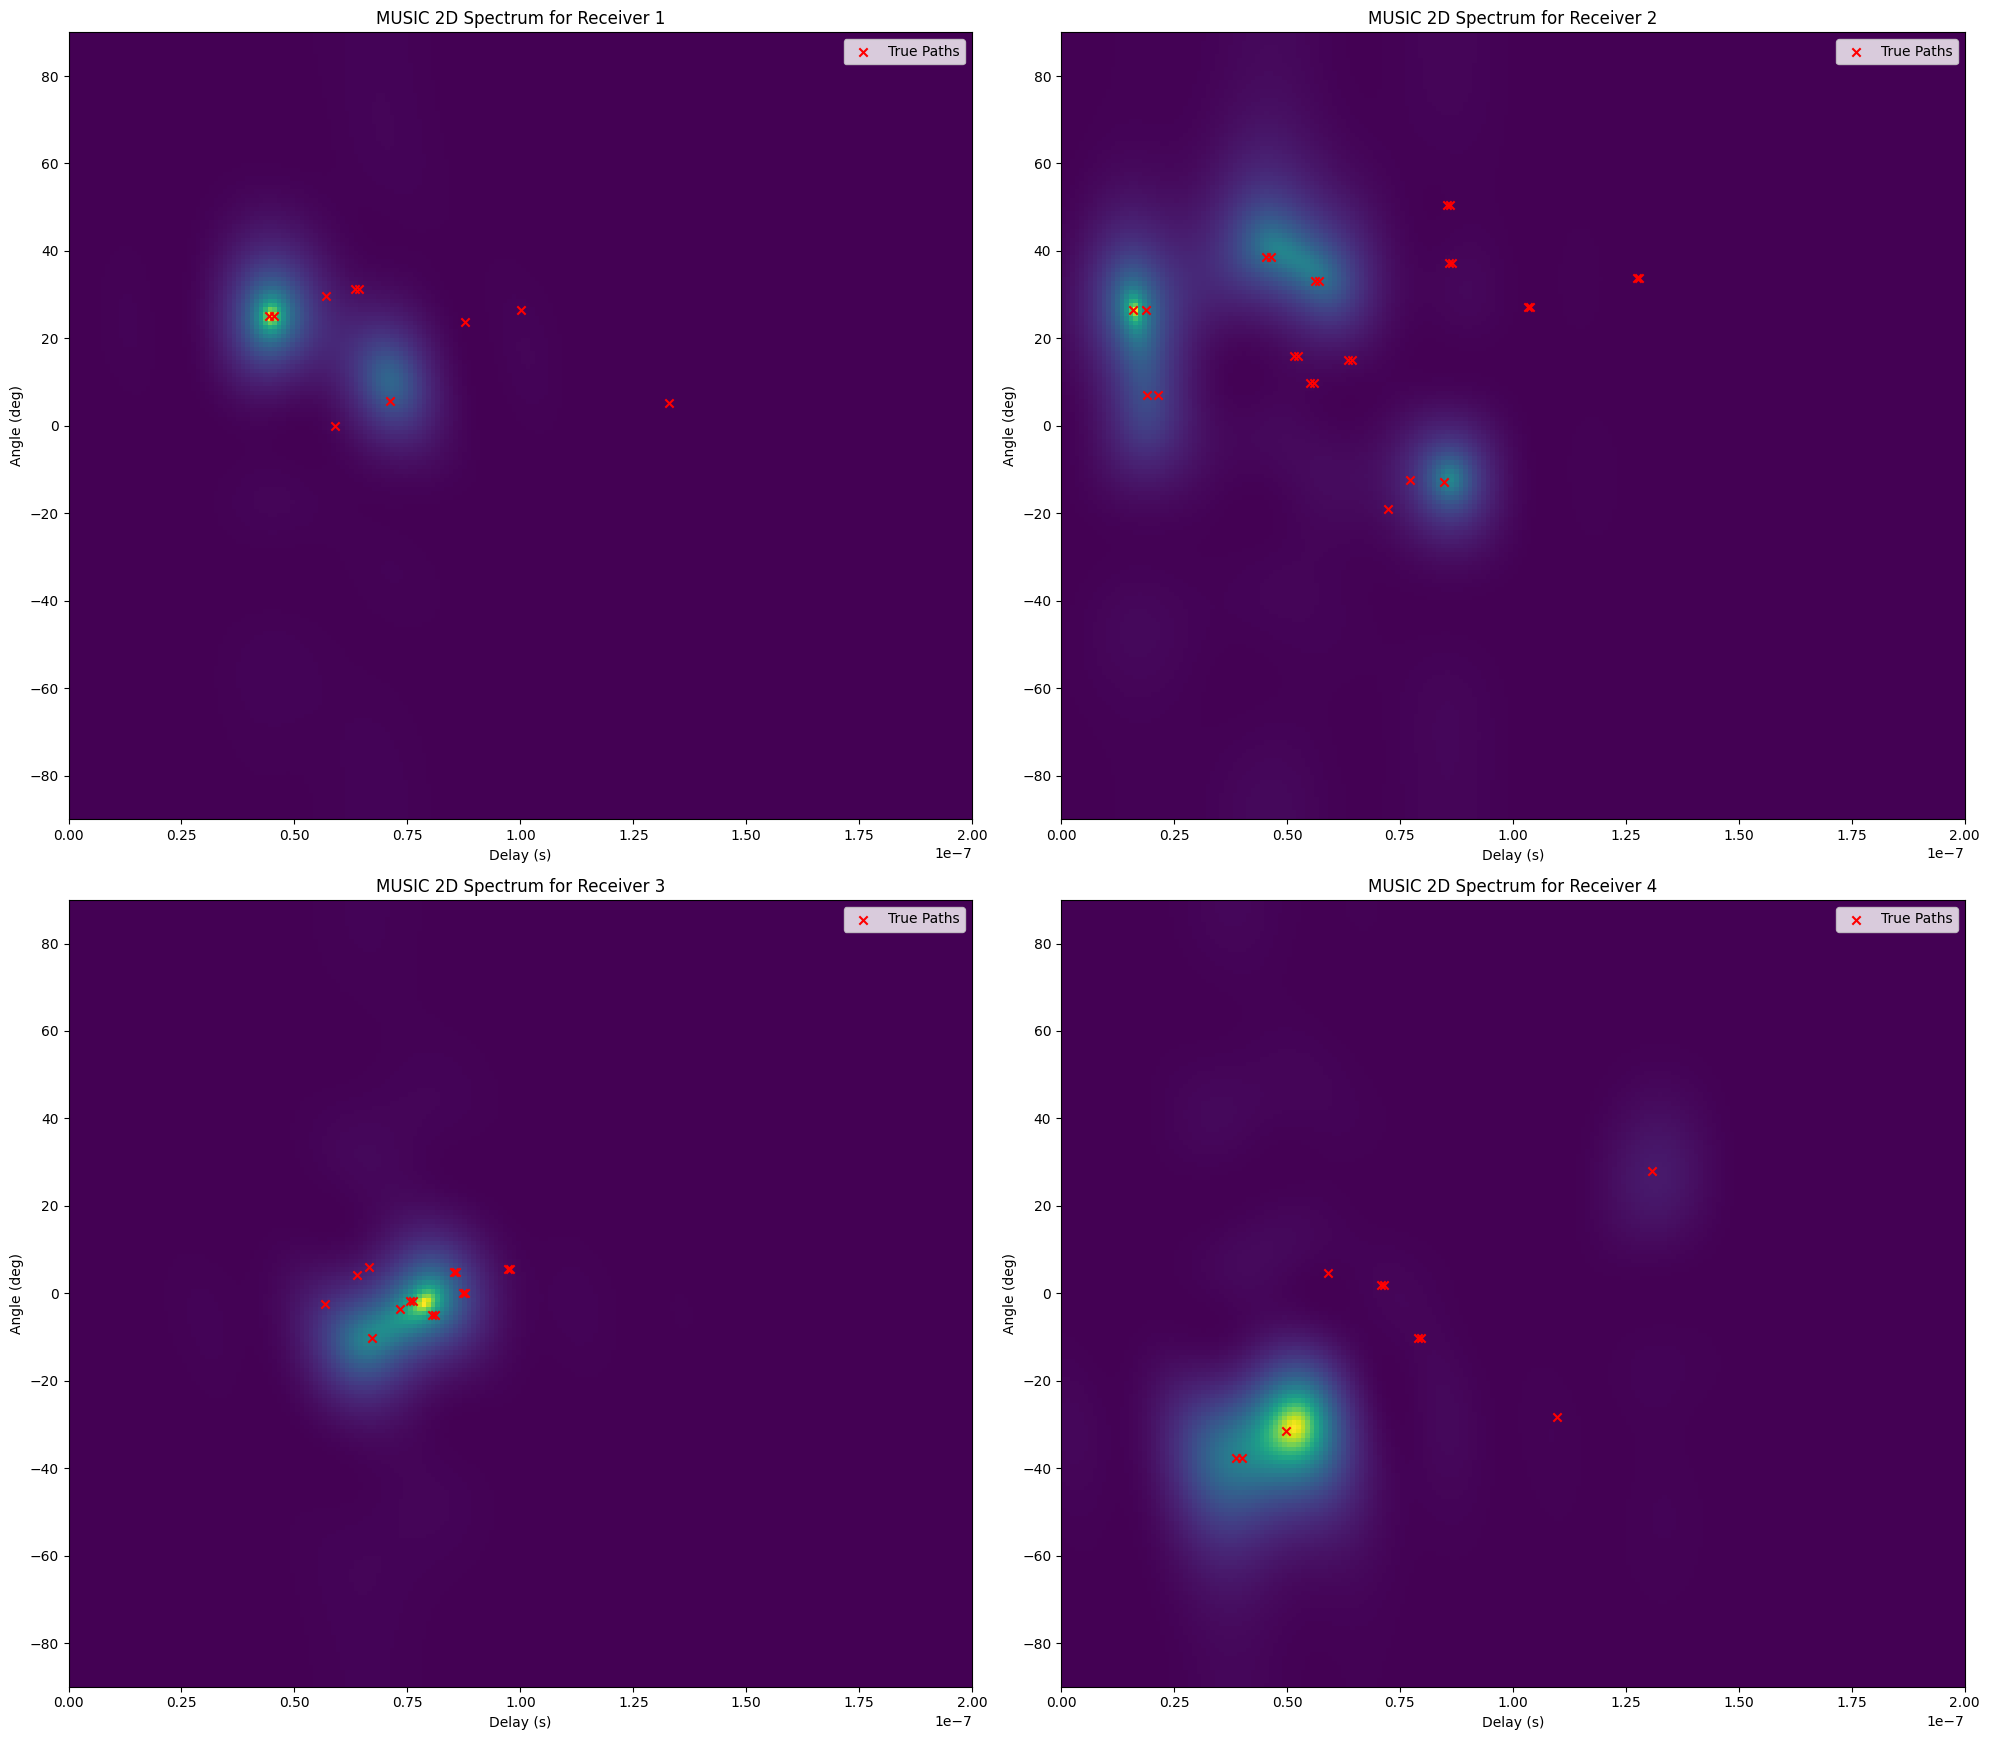

In [13]:
fig, ax = plt.subplots(num_rx//2, 2, figsize=(20, 35/8*num_rx))
for RX_idx in range(num_rx):
    ax[RX_idx//2, RX_idx%2].imshow(10*np.log10(music_spectrums[RX_idx].T), extent=(music_taus[RX_idx][0], music_taus[RX_idx][-1], music_angles[RX_idx][0]*180/np.pi, music_angles[RX_idx][-1]*180/np.pi), aspect='auto', origin='lower')
    ax[RX_idx//2, RX_idx%2].scatter(tau[RX_idx], local_angles[RX_idx]*180/np.pi, label='True Paths', color='red', marker='x')
    ax[RX_idx//2, RX_idx%2].set_title(f"MUSIC 2D Spectrum for Receiver {RX_idx+1}")
    ax[RX_idx//2, RX_idx%2].set_xlabel("Delay (s)")
    ax[RX_idx//2, RX_idx%2].set_ylabel("Angle (deg)")
    ax[RX_idx//2, RX_idx%2].legend()
plt.tight_layout()
plt.show()

In [14]:
importlib.reload(mp)

taps_hat = []
taus_hat = []
angles_hat = []
print(music_spectrums[0].shape)
for RX_idx in range(num_rx):
    music_taps, music_estimated_taus, music_estimated_angles = mp.MUSIC_2D_taps(music_spectrums[RX_idx], 
                                                                                music_taus[RX_idx], 
                                                                                music_angles[RX_idx], 
                                                                                B/fft_size, 
                                                                                music_Ks[RX_idx], 
                                                                                music_h_hats[RX_idx])
    taps_hat.append(music_taps)
    taus_hat.append(music_estimated_taus)
    angles_hat.append(music_estimated_angles)


(200, 180)


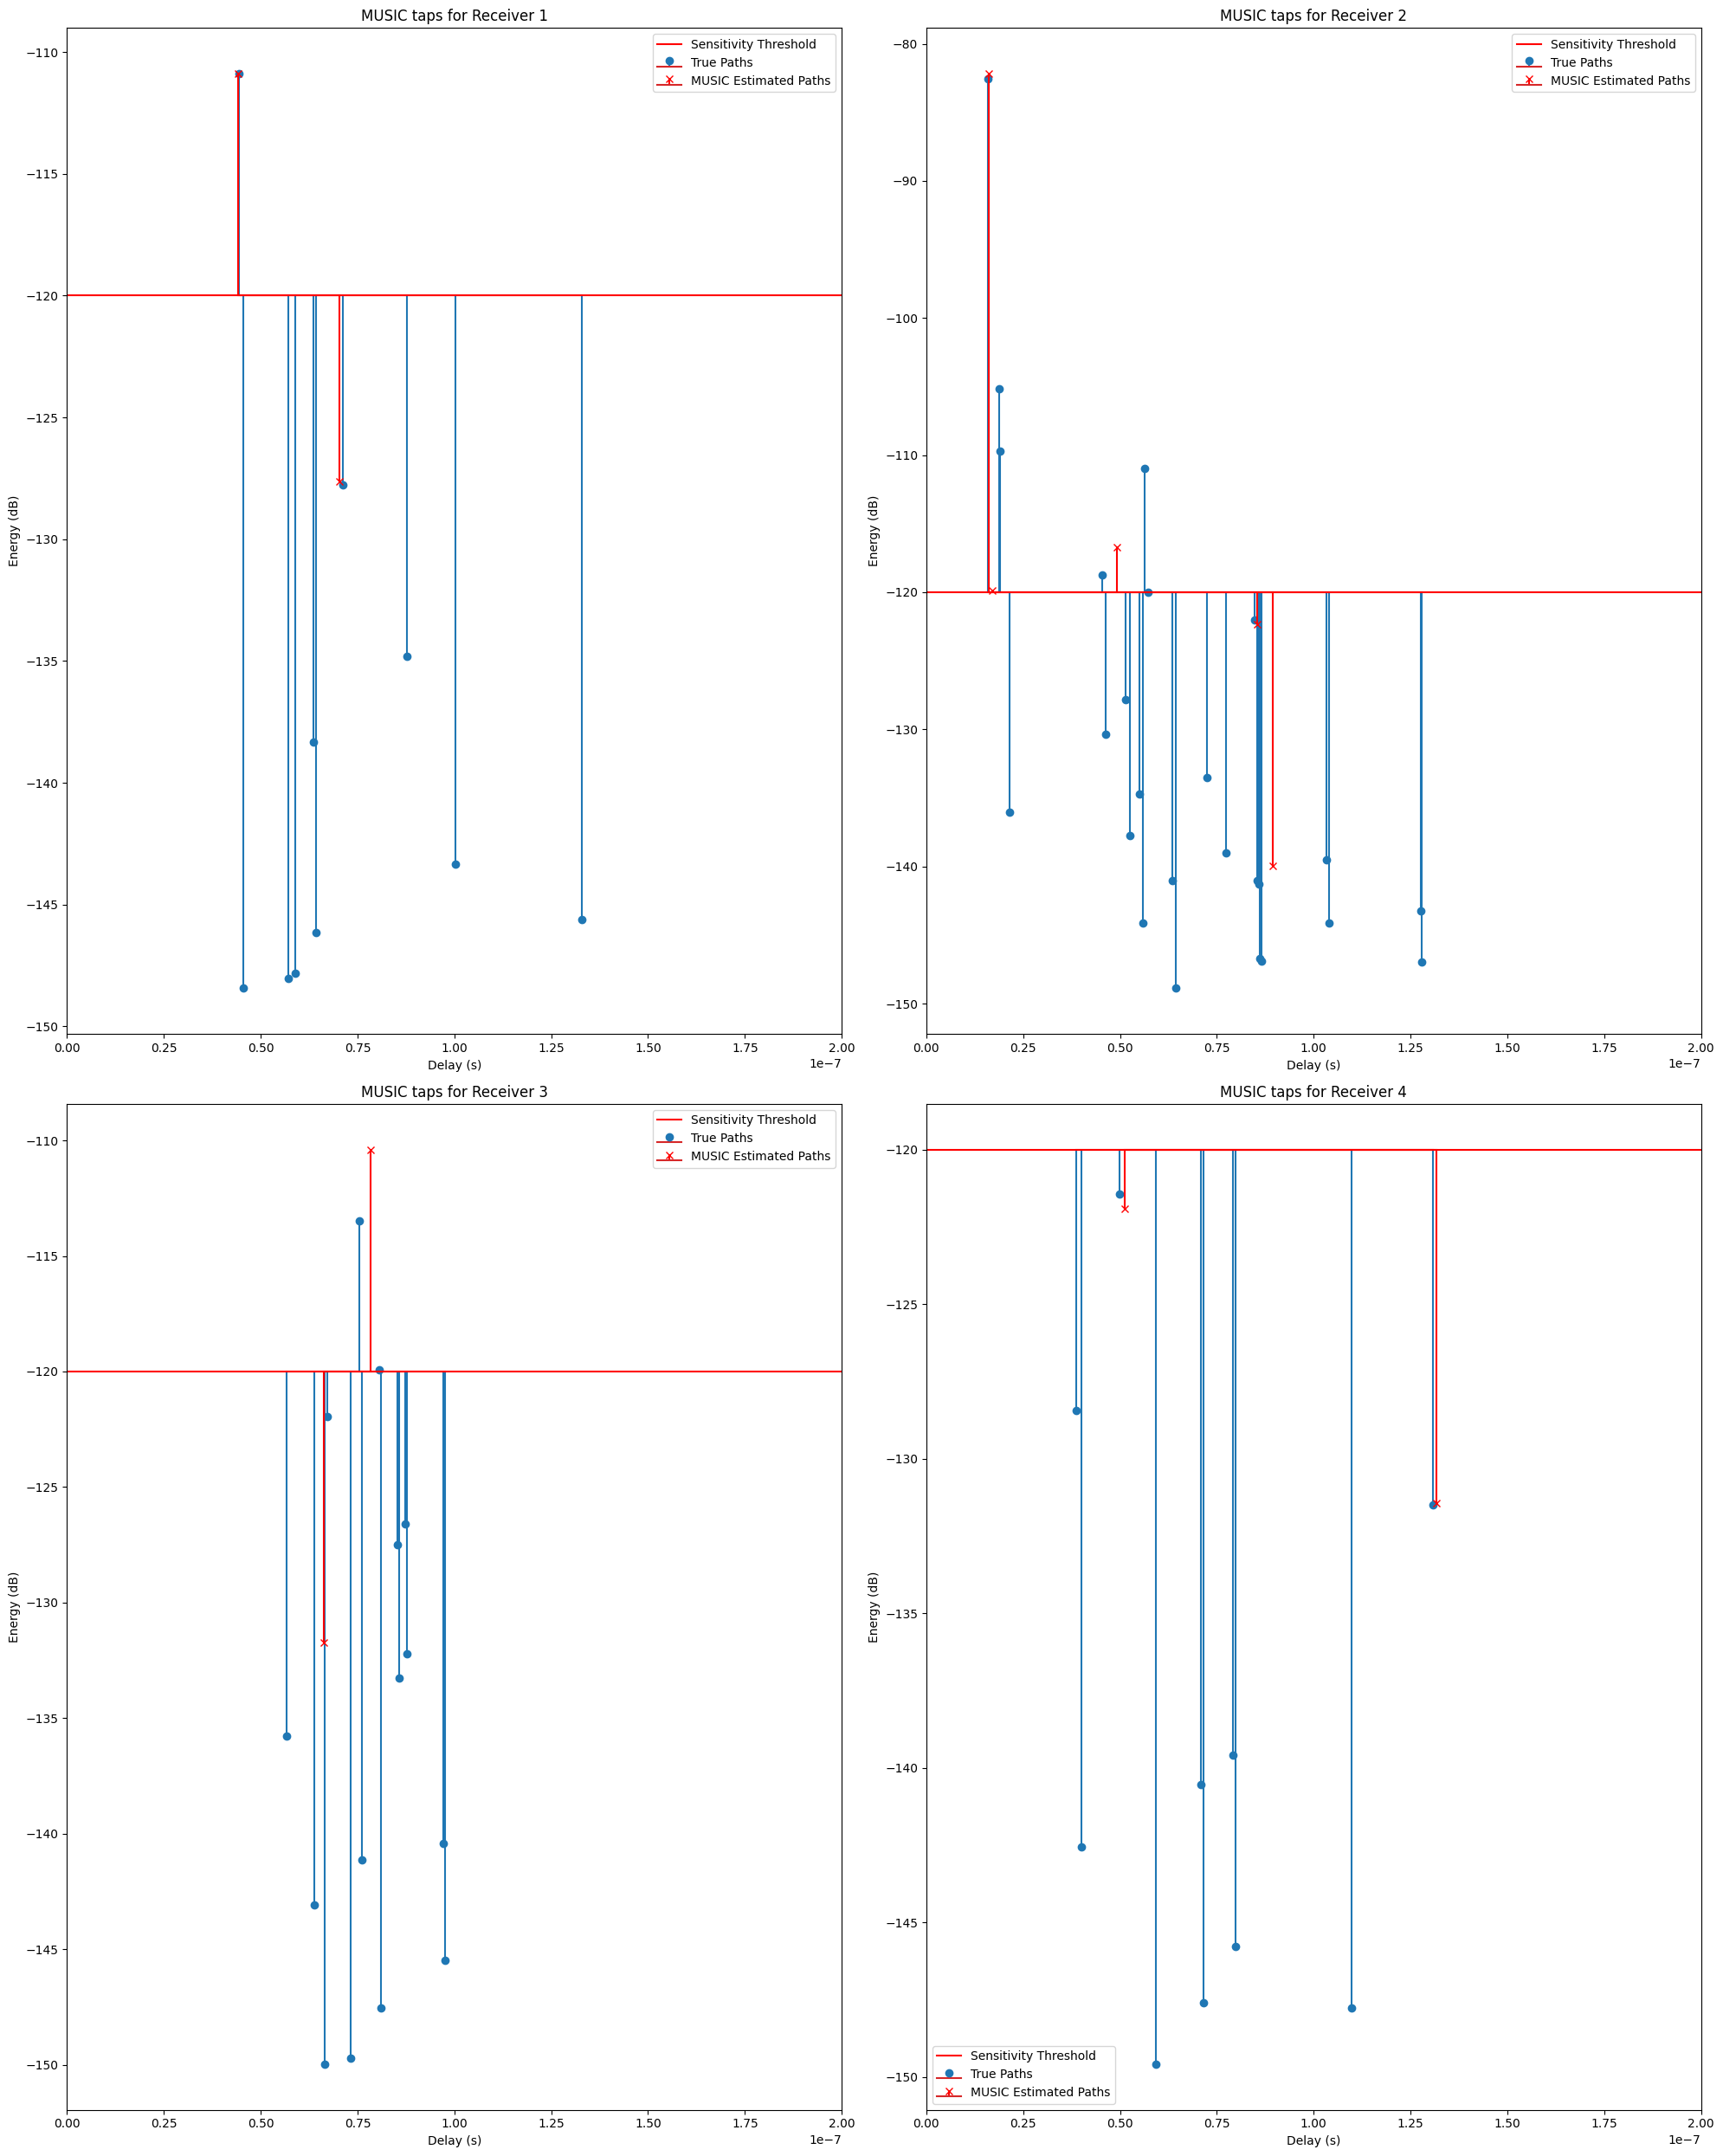

In [15]:
# Comparison of true vs estimated taps for one receiver
fig, ax = plt.subplots(num_rx//2, 2, figsize=(20, 25))
for RX_idx in range(num_rx):
    if len(taps_hat[RX_idx]) > 0:
        ax[RX_idx//2, RX_idx%2].stem(tau[RX_idx], 10*np.log10(energies[RX_idx][0]), bottom=10*np.log10(S_RX_lin), label='True Paths')
        ax[RX_idx//2, RX_idx%2].stem(taus_hat[RX_idx], 10*np.log10(np.abs(taps_hat[RX_idx])**2), bottom=10*np.log10(S_RX_lin), linefmt='r-', markerfmt='rx', label='MUSIC Estimated Paths')
        ax[RX_idx//2, RX_idx%2].axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
        ax[RX_idx//2, RX_idx%2].set_title(f"MUSIC taps for Receiver {RX_idx+1}")
        ax[RX_idx//2, RX_idx%2].set_xlabel("Delay (s)")
        ax[RX_idx//2, RX_idx%2].set_ylabel("Energy (dB)")
        ax[RX_idx//2, RX_idx%2].set_xlim(0, 2e-7)
    ax[RX_idx//2, RX_idx%2].legend()
plt.tight_layout()
plt.show()


In [16]:
import Aoa
import Tdoa
import Hybrid
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)
importlib.reload(util)

true_first_toas = [tau[RX_idx][0] if len(tau[RX_idx]) > 0 else -1 for RX_idx in range(num_rx)]
true_first_aoas = [angles[RX_idx][0] if len(angles[RX_idx]) > 0 else 4 for RX_idx in range(num_rx)]

first_toas = np.zeros(num_rx)
for RX_idx in range(num_rx):
    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
    first_toas[RX_idx] = first_toa

first_aoas = np.zeros(num_rx)
for RX_idx in range(num_rx):
    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])


# Manual correction of wrong estimates
valid_Rxs = [True for _ in range(num_rx)]
# valid_Rxs[2] = False



# for RX_idx in range(num_rx):
#     print(f"Receiver {RX_idx+1}:")
#     print(f"  True First ToA: {true_first_toas[RX_idx]:.2e} s, Estimated First ToA: {first_toas[RX_idx]:.2e} s")
#     print(f"  True First AoA: {true_first_aoas[RX_idx]*180/np.pi:.2f} deg, Estimated First AoA: {first_aoas[RX_idx]*180/np.pi:.2f} deg")


# TDOA localization using first path
TdoaLocalizer = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)
TdoaLocalizer2 = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)
TdoaLocalizer3 = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)
TdoaLocalizer4 = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)

position_estimate_tdoa = TdoaLocalizer.localize()
position_estimate_tdoa2 = TdoaLocalizer2.localize_least_squares()
position_estimate_tdoa3, residuals_record = TdoaLocalizer3.localize_weighted_least_squares(iter=2)
# position_estimate_tdoa4 = TdoaLocalizer4.localize_iterative_outlier_removal(iter=2)
print("TDOA Position Estimate:", position_estimate_tdoa)
print("TDOA Least Squares Position Estimate:", position_estimate_tdoa2)
print("TDOA Weighted Least Squares Position Estimate:", position_estimate_tdoa3)
# print("TDOA Iterative Outlier Removal Position Estimate:", position_estimate_tdoa4)

# Filtering
errors = first_toas*3e8 - np.linalg.norm(np.array(RX_positions)[:,:2] - position_estimate_tdoa2, axis=1)
errors2 = TdoaLocalizer2.detect_outliers(position_estimate_tdoa2)
print("Receiver errors (m):", errors)
print("Receiver errors2 (m):", errors2)

# fig, ax = plt.subplots(1, residuals_record.shape[1], figsize=(20, 5))
# for i in range(residuals_record.shape[1]):
#     ax[i].plot(np.abs(residuals_record[:, i]))
#     ax[i].set_title(f"Residuals for TDoA {i+1}")
#     ax[i].set_xlabel("Iteration")
#     ax[i].set_ylabel("Residual (m)")
# plt.tight_layout()
# plt.show()

# for RX_idx in range(num_rx):
#     print(f"Rx position: {RX_positions[RX_idx][:2]}")
#     print(f"Distance measured from toa: {first_toas[RX_idx]*3e8:.2f} m")
#     print(f"Actual distance from target: {np.linalg.norm(np.array(RX_positions[RX_idx][:2]) - np.array(TX_position[:2])):.2f} m")


# AOA localization using first path
AoaLocalizer = Aoa.AoaLocalization(first_aoas, [rx[:2] for rx in RX_positions])
position_estimate_aoa = AoaLocalizer.localize()
position_estimate_aoa2 = AoaLocalizer.localize_least_squares()
print("AOA Position Estimate:", position_estimate_aoa)
print("AOA Least Squares Position Estimate:", position_estimate_aoa2)

TDOA Position Estimate: [4.56218874 5.8776971 ]
TDOA Least Squares Position Estimate: [4.91210078 6.19484039]
TDOA Weighted Least Squares Position Estimate: [4.53648567 5.87156557]
Receiver errors (m): [1.2182303  2.06406185 1.36866807 1.02931261]
Receiver errors2 (m): [0.85167192 0.1458489  0.19037778 0.        ]
AOA Position Estimate: [1.83298922 5.35750008]
AOA Least Squares Position Estimate: [1.83299588 5.35746715]


In [17]:
importlib.reload(Hybrid)
importlib.reload(Tdoa)
importlib.reload(util)


HybridLocalizer2 = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
position_estimate_hybrid = HybridLocalizer2.localize()
position_estimate_hybrid_time, t0 = HybridLocalizer2.localize_time()
print("Hybrid Position Estimate with first paths only:", position_estimate_hybrid)
print("Hybrid Time-based Position Estimate:", position_estimate_hybrid_time, "with t0 =", t0)

# position_estimate_hybrid_filter = HybridLocalizer2.localize_filter()
# print("Hybrid Position Estimate with filtered paths:", position_estimate_hybrid_filter)

position_estimate_hybrid_ransac = HybridLocalizer2.localize_ransac(iter=100, threshold=0.5)
print("Hybrid Position Estimate with RANSAC:", position_estimate_hybrid_ransac)

position_estimate_hybrid_all = HybridLocalizer2.localize_all(iter=100, threshold=0.5)
print("Hybrid Position Estimate with all paths:", position_estimate_hybrid_all)

Hybrid Position Estimate with first paths only: [3.45135082 5.36485373]
Hybrid Time-based Position Estimate: [2.9978783  5.82070292] with t0 = 5.915715385019648e-09
Hybrid Position Estimate with RANSAC: [3.56465907 4.52561441]
Hybrid Position Estimate with all paths: [5.59334652 3.51109834]


### Simulation loop ###

In [24]:
importlib.reload(mp)
importlib.reload(Tdoa)
importlib.reload(Hybrid)
importlib.reload(util)

# Import scene as xml file
scene = load_scene("SimpleConfig/SimpleConfig.xml")

scene.radio_materials["itu-concrete"].thickness = 0.2

ground = ITURadioMaterial("ground",
                        "concrete",
                        thickness=1,
                        color=[0.011, 0.27, 0.8])

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

ground_object = scene.objects["elm__7"]
ground_object.radio_material = ground

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')

num_rx_ant = 4
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=num_rx_ant,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')


# Rx positions
scenario = 6

# Scenario with 4 receivers
if scenario == 4:
    num_rx = 4
    RX_positions = [[-7, 8, 1.5], 
                    [7, 8, 1.5],
                    [-7, -8, 1.5],
                    [7, -8, 1.5]]

    RX_orientations = [[-np.pi/4, 0, 0], 
                        [-3*np.pi/4, 0, 0], 
                        [np.pi/4, 0, 0],
                        [3*np.pi/4, 0, 0]]

    rx1 = Receiver("rx", RX_positions[0], RX_orientations[0])
    rx2 = Receiver("rx2", RX_positions[1], RX_orientations[1])
    rx3 = Receiver("rx3", RX_positions[2], RX_orientations[2])
    rx4 = Receiver("rx4", RX_positions[3], RX_orientations[3])

    scene.add(rx1)
    scene.add(rx2)
    scene.add(rx3)
    scene.add(rx4)

if scenario == 6:
    num_rx = 6
    RX_positions = [[-7, 8, 1.5], 
                    [7, 8, 1.5],
                    [-7, -8, 1.5],
                    [7, -8, 1.5],
                    [-9, 0, 1.5], 
                    [9, 0, 1.5]]

    RX_orientations = [[-np.pi/4, 0, 0], 
                        [-3*np.pi/4, 0, 0], 
                        [np.pi/4, 0, 0],
                        [3*np.pi/4, 0, 0],
                        [0, 0, 0],
                        [np.pi, 0, 0]]

    rx1 = Receiver("rx", RX_positions[0], RX_orientations[0])
    rx2 = Receiver("rx2", RX_positions[1], RX_orientations[1])
    rx3 = Receiver("rx3", RX_positions[2], RX_orientations[2])
    rx4 = Receiver("rx4", RX_positions[3], RX_orientations[3])
    rx5 = Receiver("rx5", RX_positions[4], RX_orientations[4])
    rx6 = Receiver("rx6", RX_positions[5], RX_orientations[5])
    scene.add(rx1)
    scene.add(rx2)
    scene.add(rx3)
    scene.add(rx4)
    scene.add(rx5)
    scene.add(rx6)

if scenario == 8:
    num_rx = 8
    RX_positions = [[-7, 8, 1.5], 
                    [0, 8, 1.5], 
                    [7, 8, 1.5], 
                    [9, 0, 1.5], 
                    [-9, 0, 1.5], 
                    [-7, -8, 1.5], 
                    [0, -8, 1.5], 
                    [7, -8, 1.5]]

    RX_orientations = [[-np.pi/4, 0, 0], 
                        [-np.pi/2, 0, 0], 
                        [-3*np.pi/4, 0, 0], 
                        [np.pi, 0, 0], 
                        [0, 0, 0], 
                        [np.pi/4, 0, 0], 
                        [np.pi/2, 0, 0], 
                        [3*np.pi/4, 0, 0]]
    
    rx1 = Receiver("rx", RX_positions[0], RX_orientations[0])
    rx2 = Receiver("rx2", RX_positions[1], RX_orientations[1])
    rx3 = Receiver("rx3", RX_positions[2], RX_orientations[2])
    rx4 = Receiver("rx4", RX_positions[3], RX_orientations[3])
    rx5 = Receiver("rx5", RX_positions[4], RX_orientations[4])
    rx6 = Receiver("rx6", RX_positions[5], RX_orientations[5])
    rx7 = Receiver("rx7", RX_positions[6], RX_orientations[6])
    rx8 = Receiver("rx8", RX_positions[7], RX_orientations[7])
    scene.add(rx1)
    scene.add(rx2)
    scene.add(rx3)
    scene.add(rx4)
    scene.add(rx5)
    scene.add(rx6)
    scene.add(rx7)
    scene.add(rx8)

# Tx positions
TX_positions = np.zeros((8, 5, 3))
x_axis = np.linspace(-7, 7, 8)
y_axis = np.linspace(-4, 4, 5)
x_axis, y_axis = np.meshgrid(x_axis, y_axis, indexing='ij')
TX_positions[:, :, 0] = x_axis
TX_positions[:, :, 1] = y_axis
TX_positions[:, :, 2] = 1.5


### System parameters ###

# Band sampling parameters
B = 100e6
T = 1 / B
osr = 8
Fs = B * osr
Ts = 1 / Fs

# Transmit power
P_TX_dBm = 0
P_TX_lin = 10 ** (P_TX_dBm / 10) / 1000

S_RX_dBm = -90
S_RX_lin = 10 ** (S_RX_dBm / 10) / 1000


### Simulation ###

for iter in range(4, 10):
    for i in range(8):
        for j in range(5):
            tx = Transmitter("tx", [float(TX_positions[i, j, 0]), float(TX_positions[i, j, 1]), float(TX_positions[i, j, 2])])
            scene.add(tx)

            pathSolver = PathSolver()
            paths = pathSolver(scene=scene, max_depth=15)


            # Channel impulse response of the path
            cir = paths.cir(sampling_frequency=3.5e9,
                            num_time_steps=1,
                            normalize_delays=False)

            angles = paths.phi_r

            a, tau, angles = util.format_paths(cir, angles, array=True)

            # Scale a with transmit power
            a = [a_i * np.sqrt(P_TX_lin) for a_i in a]

            # Energy of paths
            magnitudes = [np.abs(a[RX_idx]) for RX_idx in range(num_rx)]
            energies = [magnitudes[RX_idx]**2 for RX_idx in range(num_rx)]


            # Filter paths too weak
            threshold = -150 # in dB, relative to P_TX
            threshold_lin = 10 ** (threshold / 10)

            for RX_idx in range(num_rx):
                mask = energies[RX_idx] >= threshold_lin
                a[RX_idx] = a[RX_idx][mask].reshape(num_rx_ant, -1)
                tau[RX_idx] = tau[RX_idx][mask[0]]
                angles[RX_idx] = angles[RX_idx][mask[0]]
                magnitudes[RX_idx] = magnitudes[RX_idx][mask].reshape(num_rx_ant, -1)
                energies[RX_idx] = energies[RX_idx][mask].reshape(num_rx_ant, -1)


            music_spectrums = []
            music_taus = []
            music_angles = []
            music_Ks = []
            music_h_hats = []
            for RX_idx in range(num_rx):
                music_spectrum, music_tau, music_angle, music_K, music_h_hat = mp.MUSIC_2D_spectrum(a[RX_idx], tau[RX_idx], B, fc=3.5e9, T=5e-6, Tcir=2e-7, osr=8, fft_size=fft_size, alpha=0.1, num_pilots=10)
                music_spectrums.append(music_spectrum)
                music_taus.append(music_tau)
                music_angles.append(music_angle)
                music_Ks.append(music_K)
                music_h_hats.append(music_h_hat)


            taps_hat = []
            taus_hat = []
            angles_hat = []
            for RX_idx in range(num_rx):
                music_taps, music_estimated_taus, music_estimated_angles = mp.MUSIC_2D_taps(music_spectrums[RX_idx], 
                                                                                            music_taus[RX_idx], 
                                                                                            music_angles[RX_idx], 
                                                                                            B/fft_size, 
                                                                                            music_Ks[RX_idx], 
                                                                                            music_h_hats[RX_idx])
                taps_hat.append(music_taps)
                taus_hat.append(music_estimated_taus)
                angles_hat.append(music_estimated_angles)

            scene.remove("tx")

            # Write results to file
            filename = f"Small{scenario}/taps_estimates_{i}_{j}.csv"

            if iter == 0:
                util.clear_taps_file(filename)
            util.write_taps_to_csv(iter, taus_hat, angles_hat, TX_positions[i, j], RX_positions, RX_orientations, filename)

        


no-name-6      itu-concrete
elm__7         itu-glass


In [19]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

tdoa_errors = []
aoa_errors = []
hybrid_errors = []
hybrid_ransac_errors = []
hybrid_ransac_fo_errors = []

for i in range(8):
    for j in range(5):
        filename = f"Small8/taps_estimates_{i}_{j}.csv"
        TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

        for iter in range(1):

            taus_hat = data[f'{iter}']['delays']
            angles_hat = data[f'{iter}']['angles']

            first_toas = np.zeros(num_rx)
            for RX_idx in range(num_rx):
                first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                first_toas[RX_idx] = first_toa

            first_aoas = np.zeros(num_rx)
            for RX_idx in range(num_rx):
                first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

            # TDOA localization using first path
            TdoaLocalizer = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)
            position_estimate_tdoa = TdoaLocalizer.localize()
            tdoa_errors.append(np.linalg.norm(position_estimate_tdoa - TX_position[:2]))

            # AOA localization using first path
            AoaLocalizer = Aoa.AoaLocalization(first_aoas, [rx[:2] for rx in RX_positions])
            position_estimate_aoa = AoaLocalizer.localize_least_squares()
            aoa_errors.append(np.linalg.norm(position_estimate_aoa - TX_position[:2]))

            # Hybrid localization
            HybridLocalizer = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
            position_estimate_hybrid = HybridLocalizer.localize()
            hybrid_errors.append(np.linalg.norm(position_estimate_hybrid - TX_position[:2]))

            # Hybrid localization with RANSAC
            position_estimate_hybrid_ransac = HybridLocalizer.localize_ransac(iter=100, threshold=0.5)
            hybrid_ransac_errors.append(np.linalg.norm(position_estimate_hybrid_ransac - TX_position[:2]))

            # Hybrid localization with RANSAC + first-order reflections
            try:
                position_estimate_hybrid_ransac_fo = HybridLocalizer.localize_iterative2(iter=100, threshold=0.5)
                hybrid_ransac_fo_errors.append(np.linalg.norm(position_estimate_hybrid_ransac_fo - TX_position[:2]))
            except Exception as e:
                print(f"Error occurred while localizing with RANSAC + FO: {e}")
                print(taus_hat)

Ransac iteration: nb_inliers = 19
Ransac iteration: nb_inliers = 22
Ransac iteration: nb_inliers = 22
Ransac iteration: nb_inliers = 18
Ransac iteration: nb_inliers = 18
Ransac iteration: nb_inliers = 18
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 14
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 12
Ransac iteration: nb_inliers = 14
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 15
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 13
Ransac iteration: nb_inliers = 13
Ransac iterati

RMSE TDOA: 184754046.53 m
RMSE AOA: 5.23 m
RMSE Hybrid: 1.87 m
RMSE Hybrid RANSAC: 0.36 m
RMSE Hybrid RANSAC FO: 0.25 m


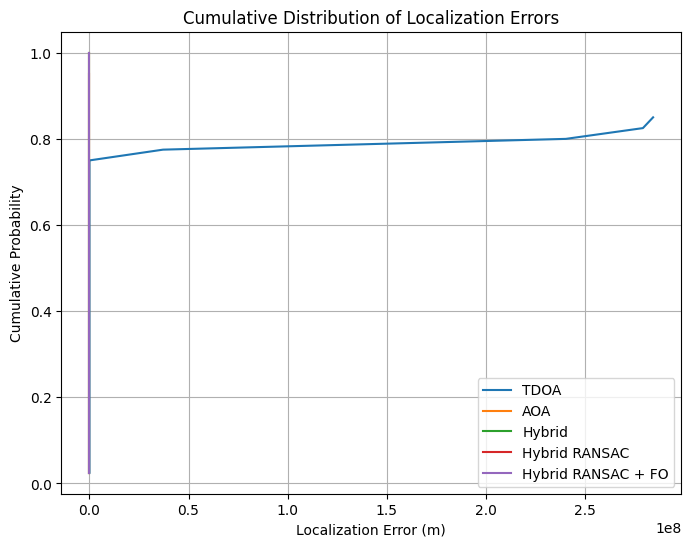

In [20]:
tdoa_errors = np.array(tdoa_errors)
aoa_errors = np.array(aoa_errors)
hybrid_errors = np.array(hybrid_errors)
hybrid_ransac_errors = np.array(hybrid_ransac_errors)
hybrid_ransac_fo_errors = np.array(hybrid_ransac_fo_errors)

rmse_tdoa = np.sqrt(np.mean(tdoa_errors**2))
rmse_aoa = np.sqrt(np.mean(aoa_errors**2))
rmse_hybrid = np.sqrt(np.mean(hybrid_errors**2))
rmse_hybrid_ransac = np.sqrt(np.mean(hybrid_ransac_errors**2))
rmse_hybrid_ransac_fo = np.sqrt(np.mean(hybrid_ransac_fo_errors**2))

print(f"RMSE TDOA: {rmse_tdoa:.2f} m")
print(f"RMSE AOA: {rmse_aoa:.2f} m")
print(f"RMSE Hybrid: {rmse_hybrid:.2f} m")
print(f"RMSE Hybrid RANSAC: {rmse_hybrid_ransac:.2f} m")
print(f"RMSE Hybrid RANSAC FO: {rmse_hybrid_ransac_fo:.2f} m")

cum = np.arange(1, len(tdoa_errors)+1) / len(tdoa_errors)

tdoa_errors_sorted = np.sort(tdoa_errors)
aoa_errors_sorted = np.sort(aoa_errors)
hybrid_errors_sorted = np.sort(hybrid_errors)
hybrid_ransac_errors_sorted = np.sort(hybrid_ransac_errors)
hybrid_ransac_fo_errors_sorted = np.sort(hybrid_ransac_fo_errors)

plt.figure(figsize=(8, 6))
plt.plot(tdoa_errors_sorted[:-6], cum[:-6], label='TDOA')
plt.plot(aoa_errors_sorted, cum, label='AOA')
plt.plot(hybrid_errors_sorted, cum, label='Hybrid')
plt.plot(hybrid_ransac_errors_sorted[:-2], cum[:-2], label='Hybrid RANSAC')
plt.plot(hybrid_ransac_fo_errors_sorted, cum, label='Hybrid RANSAC + FO')
plt.xlabel("Localization Error (m)")
plt.ylabel("Cumulative Probability")
plt.title("Cumulative Distribution of Localization Errors")
plt.legend()
plt.grid()
plt.show()
